In [1]:
pip install polars elfen spacy

  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached transformers-4.36.2-py3-none-any.whl.metadata (126 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.15.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.7 kB)
Using cached requests-2.32.3-py3-none-any.whl (64 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
Using cached transformers-4.36.2-py3-none-any.whl (8.2 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.15.2-cp312-cp312-macosx_11_0_arm64.whl (2.4 MB)
  Attempting uninstall: Requests
    Found existing installation: requests 2.34.2
    Uninstalling requests-2.34.2:
      Successfully uninstalled requests-2.34.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.2
    Uninstalling numpy-2.5.2:
      Successfully uninstalled numpy-2.5.

In [11]:
import polars as pl
from pathlib import Path

folder = Path("/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster")
csv_files = list(folder.glob("*.csv"))

dataframes = {}

for f in csv_files:
    key = f.stem.split("_")[0]
    print(f)
    print(key)
    dataframes[key] = pl.read_csv(f)

/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/QWEN_dataset_experiment_results.csv
QWEN
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/HuggingFaceTB_dataset_experiment_results.csv
HuggingFaceTB
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/mistralai_dataset_experiment_results.csv
mistralai
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/google_dataset_experiment_results.csv
google
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/meta-llama_dataset_experiment_results.csv
meta-llama


In [20]:
for key in dataframes:
    print(type(key))


<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


In [17]:
dataframes["QWEN"].head()

question_id,dataset_source,first_token_answer,unconstrained_text,parsed_text_answer,is_mismatch,top_1st_token_logprobs
str,str,str,str,str,bool,str
"""Q_0""","""OpinionQA""","""A""","""As an artificial intelligence …","""A""",false,"""{32: Logprob(logprob=-5.316593…"
"""Q_1""","""MMLU""","""C""","""The excerpt from Frederick Dou…","""C""",false,"""{34: Logprob(logprob=-0.000229…"
"""Q_2""","""MMLU""","""A""","""Bartering as a form of payment…","""Refusal/Unclear""",true,"""{32: Logprob(logprob=-0.027164…"
"""Q_3""","""MMLU""","""C""","""According to trials on diabete…","""C""",false,"""{34: Logprob(logprob=-0.000168…"
"""Q_4""","""OpinionQA""","""A""","""When considering whether medic…","""A""",false,"""{32: Logprob(logprob=-7.998623…"


In [ ]:
#  !Python -m spacy download en_core_web_sm

In [32]:
def elfen_feature(data, key):

    import elfen
    from elfen import Extractor

    # ----------------------------------------------------
    # B. initializing Elfen
    # ----------------------------------------------------
    print("\nInitializing elfen feature extractor...")
    extractor = Extractor(
        data,
        language="en",
        backbone="spacy",
        text_column="unconstrained_text"
    )

    print("Extracting 1,061 linguistic features...")
    extractor.extract_features()
    df_features = extractor.get_data()



    import polars as pl

    # Iterate over columns and cast any remaining Object, List, or Struct columns to String
    # This is a more robust way to ensure all complex/nested objects are converted to a string representation
    for col in df_features.columns:
        if df_features[col].dtype in (pl.Object, pl.List, pl.Struct):
            df_features = df_features.with_columns(
                pl.col(col).map_elements(lambda x: str(x), return_dtype=pl.String)
            )

    # Now Polars can safely write it to a CSV
    df_features.write_csv(f"{key}_sample_features.csv")

In [ ]:
#.  NO RUN CELL

import polars as pl

# Iterate over columns and cast any remaining Object, List, or Struct columns to String
# This is a more robust way to ensure all complex/nested objects are converted to a string representation
for col in df_features.columns:
    if df_features[col].dtype in (pl.Object, pl.List, pl.Struct):
        df_features = df_features.with_columns(
            pl.col(col).map_elements(lambda x: str(x), return_dtype=pl.String)
        )

# Now Polars can safely write it to a CSV
df_features.write_csv("opinionqa_sample_features.csv")

In [22]:
# !pip install scikit-bio   # FOR MENTAL TEST FUNCTION 

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from skbio.stats.distance import mantel

In [23]:
def ling_finger(data, key):

    # 1. Load the exported feature dataset
    df = pl.read_csv(data)

    # 2. Separate metadata columns from numeric linguistic features
    metadata_cols = ["question_id", "first_token_answer", "unconstrained_text", "parsed_text_answer", "is_mismatch"]
    feature_cols = [col for col in df.columns if col not in metadata_cols]

    print(f"Total Rows Analyzed: {len(df)}")
    print(f"Total Linguistic Features: {len(feature_cols)}")
    print(f"Overall Mismatch Rate: {df['is_mismatch'].mean():.2%}")

    # 3. Identify Top Distinguishing Linguistic Features (Matched vs. Mismatched)
    df_pd = df.to_pandas()

    # Convert boolean mismatch to integer for correlation
    df_pd["mismatch_numeric"] = df_pd["is_mismatch"].astype(int)

    # Filter strictly numeric feature columns
    numeric_features = df_pd[feature_cols].select_dtypes(include=[np.number]).columns

    # Calculate correlation between linguistic features and mismatch occurrence
    correlations = df_pd[numeric_features].apply(lambda x: x.corr(df_pd["mismatch_numeric"])).dropna()

    # Sort top positively and negatively correlated features
    top_features = correlations.abs().sort_values(ascending=False).head(10)
    print("\n--- TOP 10 CORRELATED LINGUISTIC FEATURES ---")
    print(correlations[top_features.index])

    # 4. Generate Poster Visual: Top Feature Importance Bar Chart
    plt.figure(figsize=(10, 5))
    sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")
    plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
    plt.title("Top Linguistic Fingerprints Driving Evaluation Instability (is_mismatch)", fontsize=13, pad=12)
    plt.xlabel("Correlation with Mismatch (r)", fontsize=11)
    plt.ylabel("elfen Linguistic Feature", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{key}_feature_importance_poster.png", dpi=300)
    plt.show()

In [24]:
def mismatch_plot(data, key):

        #Load the exported feature dataset
        df = pl.read_csv(data)

        # 1. Filter the dataset to ONLY include rows where an evaluation mismatch occurred
        mismatched_df = df.filter(pl.col("is_mismatch") == True)

        # 2. Count the types of mismatches
        # "Refusals" are cases where the regex parser couldn't find a valid A/B/C/D answer
        # "Stance Flips" are cases where the model picked a valid option, but it was DIFFERENT from the first token
        refusals_count = mismatched_df.filter(pl.col("parsed_text_answer") == "Refusal/Unclear").height
        stance_flips_count = mismatched_df.filter(pl.col("parsed_text_answer") != "Refusal/Unclear").height

        # 3. Prepare data for the pie chart
        labels = ['Safety Refusals\n(Guardrails Triggered)', 'Genuine Stance Flips\n(Chose Different Option)']
        sizes = [refusals_count, stance_flips_count]
        colors = ['#ff9999', '#66b3ff']
        explode = (0.1, 0)  # slightly separate the Refusals slice for visual emphasis

        # 4. Generate the Pie Chart
        plt.figure(figsize=(8, 6))
        plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
                shadow=True, startangle=140, textprops={'fontsize': 12})

        plt.title('What Caused the Evaluation Mismatches?', fontsize=16, pad=20)
        plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle

        # 5. Save and Display
        plt.savefig(f"{key}_refusal_breakdown_pie_chart.png", dpi=300, bbox_inches='tight')
        plt.show()

        # Print the raw numbers for your records
        print(f"Total Mismatches Analyzed: {len(mismatched_df)}")
        print(f"Mismatches due to Safety Refusals: {refusals_count}")
        print(f"Mismatches due to Stance Flips: {stance_flips_count}")

In [25]:
def tSNE(data, key):

    #Load the exported feature dataset
    df = pl.read_csv(data)
    print("Preparing data for t-SNE...")
    # 1. Convert to Pandas for scikit-learn compatibility
    df_pd = df.to_pandas()

    # 2. Create a specific labeling column to color our clusters
    def categorize_response(row):
        if row['is_mismatch'] == False:
            return 'Match (Stable)'
        elif row['parsed_text_answer'] == 'Refusal/Unclear':
            return 'Safety Refusal (Outlier)'
        else:
            return 'Stance Flip'

    df_pd['Response_Category'] = df_pd.apply(categorize_response, axis=1)

    # 3. Isolate strictly numeric linguistic features
    metadata_cols = [
        "question_id", "first_token_answer", "unconstrained_text",
        "parsed_text_answer", "is_mismatch", "Response_Category"
    ]
    feature_cols = [col for col in df_pd.columns if col not in metadata_cols]
    numeric_features = df_pd[feature_cols].select_dtypes(include=[np.number])

    # Replace inf/-inf with NaN, then fill all NaN (including former infs) with 0
    numeric_features = numeric_features.replace([np.inf, -np.inf], np.nan)
    numeric_features = numeric_features.fillna(0)

    print("Scaling features...")
    # 4. Standardize the data (t-SNE is highly sensitive to differing scales)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(numeric_features)

    print("Running t-SNE projection (this may take a moment)...")
    # 5. Run the t-SNE algorithm
    # Note: perplexity must be less than the number of samples.
    # We use a dynamic calculation to prevent errors on small sample sizes.
    perplexity_value = min(30, len(df_pd) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value)
    tsne_results = tsne.fit_transform(scaled_features)

    # Attach results back to the DataFrame
    df_pd['tsne_1'] = tsne_results[:, 0]
    df_pd['tsne_2'] = tsne_results[:, 1]

    print("Plotting the clusters...")
    # 6. Generate the Scatter Plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='tsne_1', y='tsne_2',
        hue='Response_Category',
        palette={'Match (Stable)': '#2ca02c', 'Stance Flip': '#1f77b4', 'Safety Refusal (Outlier)': '#d62728'},
        data=df_pd,
        alpha=0.8,
        s=80,
        edgecolor='w',
        linewidth=0.5
    )

    plt.title('t-SNE Projection of Linguistic Fingerprints', fontsize=16, pad=15)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.legend(title='Evaluation Outcome', title_fontsize='11', fontsize='10', loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"{key}_tsne_linguistic_clusters.png", dpi=300)
    plt.show()

In [40]:

def LOF(data, key):
    import polars as pl
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    from sklearn.neighbors import LocalOutlierFactor
    import matplotlib.pyplot as plt
    import seaborn as sns

    # 1. Load the exported feature dataset
    # Update the filename if your CSV has a different name
    df = pl.read_csv(data)
    df_pd = df.to_pandas()

    # 2. Isolate strictly numeric linguistic features
    metadata_cols = [
        "question_id", "first_token_answer", "unconstrained_text", 
        "parsed_text_answer", "is_mismatch", "Dataset_Source", "Response_Category"
    ]
    feature_cols = [col for col in df_pd.columns if col not in metadata_cols]
    numeric_features = df_pd[feature_cols].select_dtypes(include=[np.number])

    # Fill any missing values with 0 so the math doesn't crash
    numeric_features = numeric_features.replace([np.inf, -np.inf], np.nan).fillna(0)

    # 3. Standardize the data (Crucial for LOF since it relies on distance metrics)
    print("Scaling features...")
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(numeric_features)

    # 4. Initialize and fit the Local Outlier Factor model
    print("Running LOF outlier detection...")
    # contamination=0.05 assumes roughly 5% of your dataset will be extreme structural outliers
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
    outlier_predictions = lof.fit_predict(scaled_features)

    # LOF returns 1 for inliers (normal) and -1 for outliers.
    # Convert this to a clean Boolean column:
    df_pd['is_structural_outlier'] = (outlier_predictions == -1)

    # 5. Analyze the Results: Do Outliers align with Mismatches?
    print(f"\n--- LOF OUTLIER SUMMARY for {key}---")
    print(f"Total rows analyzed: {len(df_pd)}")
    print(f"Total Structural Outliers Detected: {df_pd['is_structural_outlier'].sum()}")

    print("\n--- CROSS-TABULATION: OUTLIERS vs. MISMATCHES ---")
    cross_tab = pd.crosstab(
        df_pd['is_structural_outlier'], 
        df_pd['is_mismatch'], 
        rownames=['Is Structural Outlier?'], 
        colnames=['Is Evaluation Mismatch?']
    )
    print(cross_tab) 

In [38]:
# !pip install scikit-bio

def Ling_Shift(data, key):
    import polars as pl
    import pandas as pd
    import numpy as np
    from skbio.stats.distance import mantel

    # 1. Load your extracted features
    df = pl.read_csv(data).to_pandas()

    # 2. Separate the dataset into the two Output Types
    df_match = df[df['is_mismatch'] == False]
    df_mismatch = df[df['is_mismatch'] == True]

    # 3. Isolate strictly numeric linguistic features
    metadata_cols = [
        "question_id", "first_token_answer", "unconstrained_text", 
        "parsed_text_answer", "is_mismatch", "Dataset_Source", 
        "is_structural_outlier", "top_1st_token_logprobs"
    ]
    feature_cols = [col for col in df.columns if col not in metadata_cols]

    num_match = df_match[feature_cols].select_dtypes(include=[np.number]).fillna(0)
    num_mismatch = df_mismatch[feature_cols].select_dtypes(include=[np.number]).fillna(0)

    # 4. Compute the Feature-by-Feature Correlation Matrices
    print("Computing correlation structures (this may take a moment)...")
    # We calculate how every linguistic feature correlates with every other feature
    corr_match = num_match.corr().fillna(0).values
    corr_mismatch = num_mismatch.corr().fillna(0).values

    # 5. Convert Correlation to Distance Matrices
    # The Mantel test requires distance matrices (Distance = 1 - absolute correlation)
    dist_match = 1 - np.abs(corr_match)
    dist_mismatch = 1 - np.abs(corr_mismatch)

    # Ensure the diagonals are exactly 0 (a mathematical requirement for distance matrices)
    np.fill_diagonal(dist_match, 0)
    np.fill_diagonal(dist_mismatch, 0)

    # 6. Run the Mantel Test
    print(f"Running Mantel test...{key}")
    # permutations=999 is the academic standard for calculating the p-value
    stat, p_value, _ = mantel(dist_match, dist_mismatch, permutations=999)

    print("\n--- MANTEL TEST RESULTS ---")
    print(f"Mantel Correlation (r): {stat:.4f}")
    print(f"P-value: {p_value:.4f}")

In [42]:
for key in dataframes:
    print(f"Starting the visualization of {key}")
    print("--------------------------------------")
    csv = f"{key}_sample_features.csv"
    
    #elfen_feature(dataframes[key], key)
    LOF(csv, key)
    Ling_Shift(csv, key)
    print("##########################################\n")

Starting the visualization of QWEN
--------------------------------------
Scaling features...
Running LOF outlier detection...

--- LOF OUTLIER SUMMARY for QWEN---
Total rows analyzed: 900
Total Structural Outliers Detected: 45

--- CROSS-TABULATION: OUTLIERS vs. MISMATCHES ---
Is Evaluation Mismatch?  False  True 
Is Structural Outlier?               
False                      463    392
True                        20     25
Computing correlation structures (this may take a moment)...
Running Mantel test...QWEN

--- MANTEL TEST RESULTS ---
Mantel Correlation (r): 0.9385
P-value: 0.0010
##########################################

Starting the visualization of HuggingFaceTB
--------------------------------------
Scaling features...
Running LOF outlier detection...

--- LOF OUTLIER SUMMARY for HuggingFaceTB---
Total rows analyzed: 900
Total Structural Outliers Detected: 45

--- CROSS-TABULATION: OUTLIERS vs. MISMATCHES ---
Is Evaluation Mismatch?  False  True 
Is Structural Outlier?    

Starting the visualization of QWEN
--------------------------------------
Total Rows Analyzed: 900
Total Linguistic Features: 305
Overall Mismatch Rate: 46.33%


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_73550/2550495056.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")



--- TOP 10 CORRELATED LINGUISTIC FEATURES ---
avg_word_length       -0.155526
cli                   -0.151472
lexical_density       -0.147538
avg_sd_aoa            -0.141986
avg_aoa               -0.139957
n_entities             0.135204
lix                   -0.133437
n_dependency_nummod    0.127909
rix                   -0.121209
n_num                  0.119026
dtype: float64


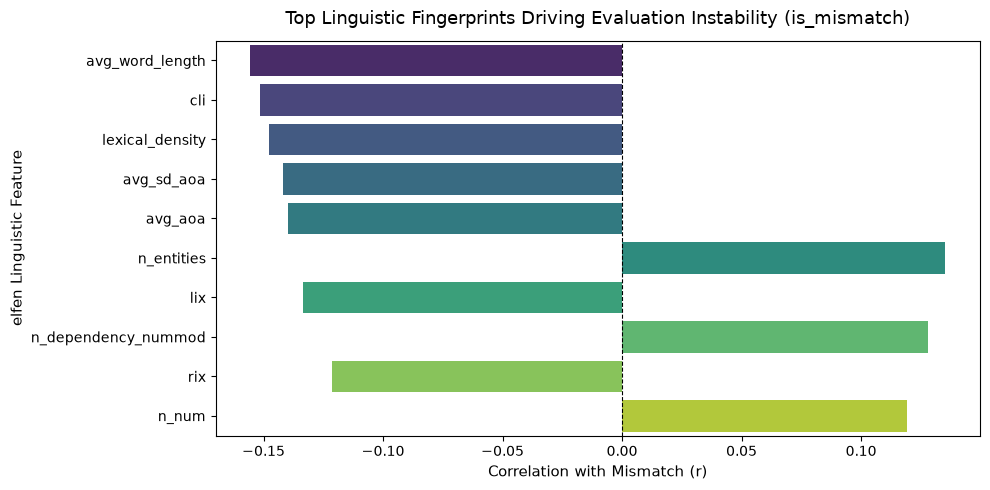

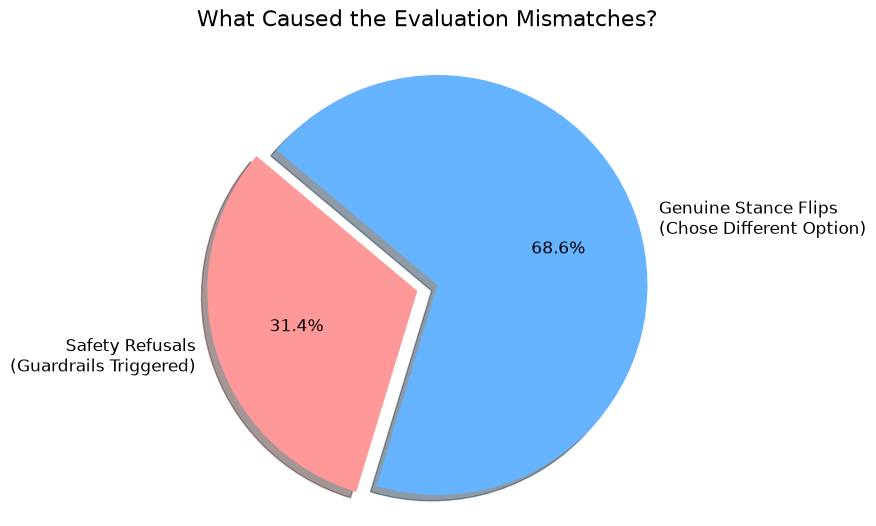

Total Mismatches Analyzed: 417
Mismatches due to Safety Refusals: 131
Mismatches due to Stance Flips: 286
Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


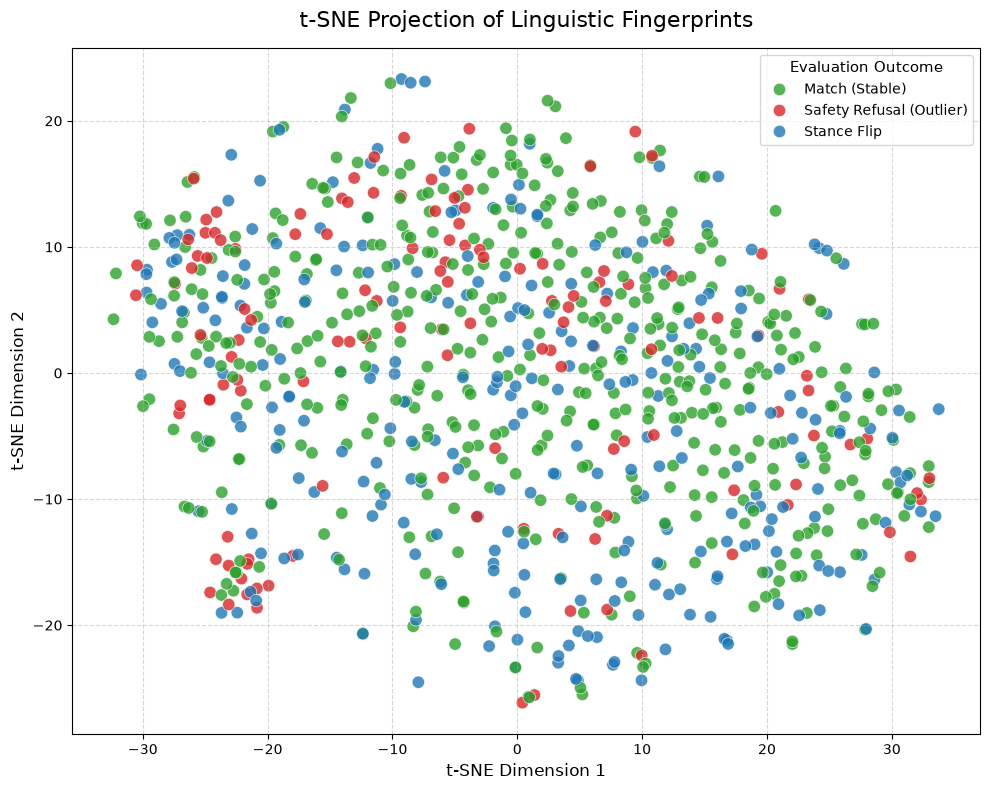

##########################################
Starting the visualization of HuggingFaceTB
--------------------------------------
Total Rows Analyzed: 900
Total Linguistic Features: 302
Overall Mismatch Rate: 49.33%

--- TOP 10 CORRELATED LINGUISTIC FEATURES ---
avg_dominance       -0.212447
avg_aoa             -0.180850
mtld                -0.170801
dougast_u           -0.169114
summer_index        -0.166027
lemma_token_ratio   -0.164087
cli                 -0.163773
herdan_c            -0.162801
smog                -0.160261
avg_word_length     -0.157840
dtype: float64


/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_73550/2550495056.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")


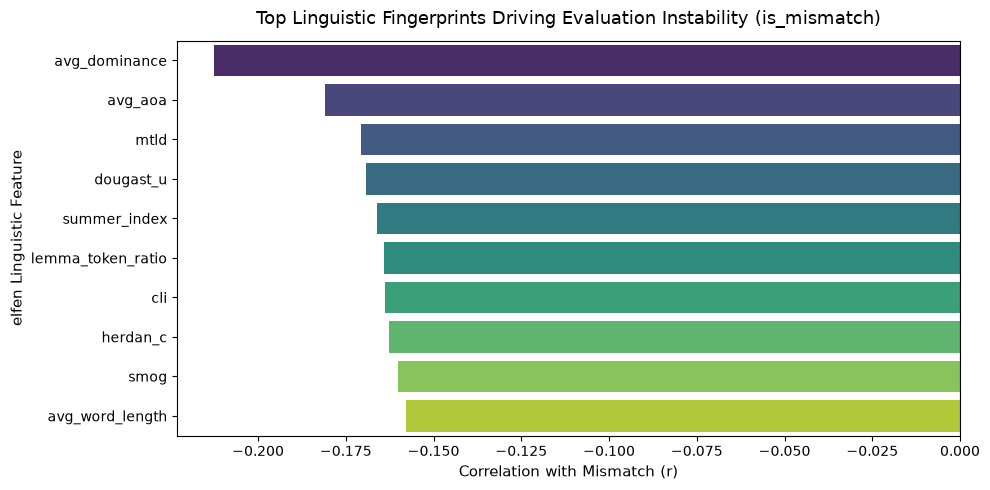

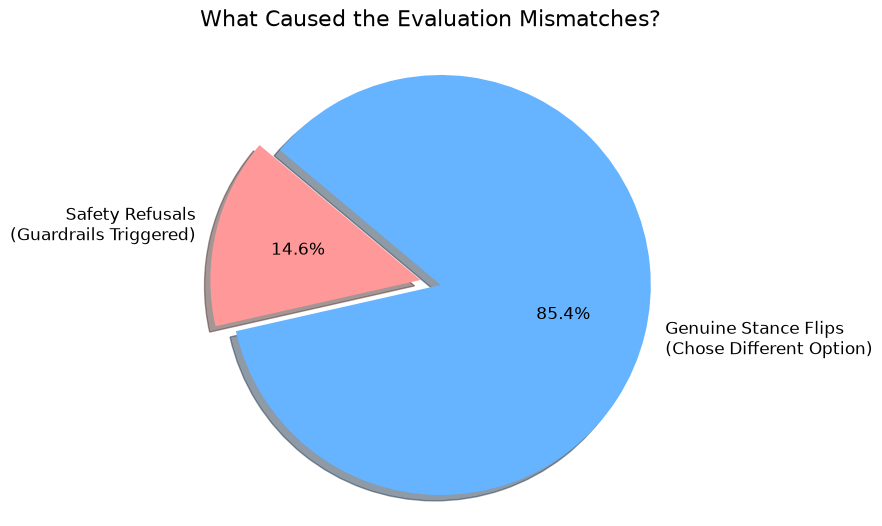

Total Mismatches Analyzed: 444
Mismatches due to Safety Refusals: 65
Mismatches due to Stance Flips: 379
Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


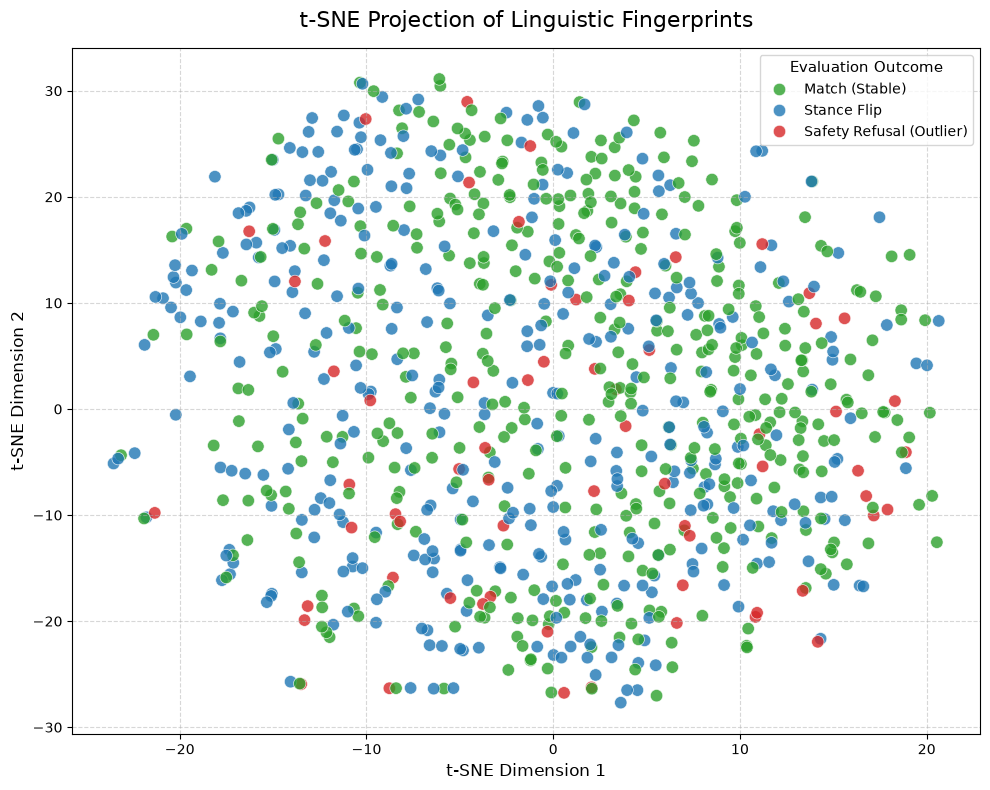

##########################################
Starting the visualization of mistralai
--------------------------------------
Total Rows Analyzed: 900
Total Linguistic Features: 302
Overall Mismatch Rate: 29.33%

--- TOP 10 CORRELATED LINGUISTIC FEATURES ---
n_num                  0.176634
n_NUM_NumType_Card     0.176634
n_entities             0.171083
n_cardinal             0.164974
n_dependency_nummod    0.143179
entropy                0.134604
n_ordinal              0.126675
lexical_density       -0.124323
avg_arousal           -0.118257
n_sym                  0.117974
dtype: float64


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_73550/2550495056.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")


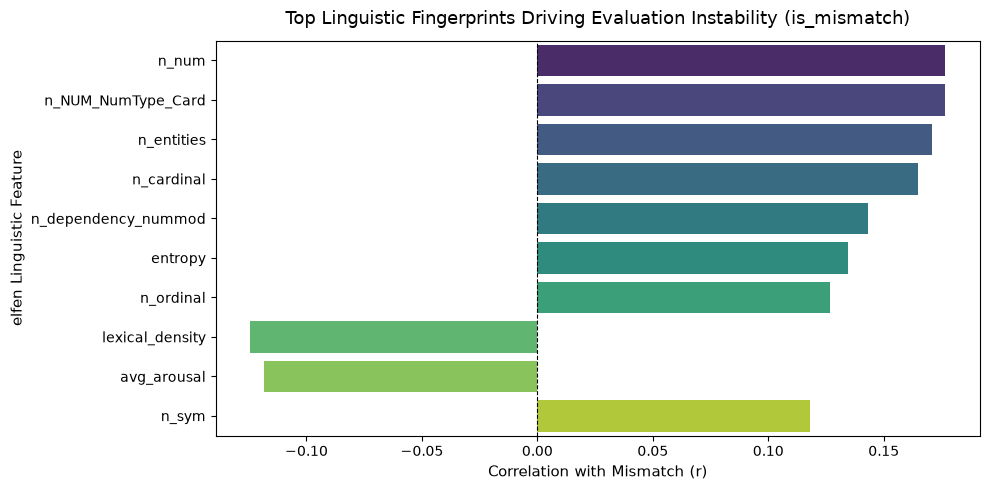

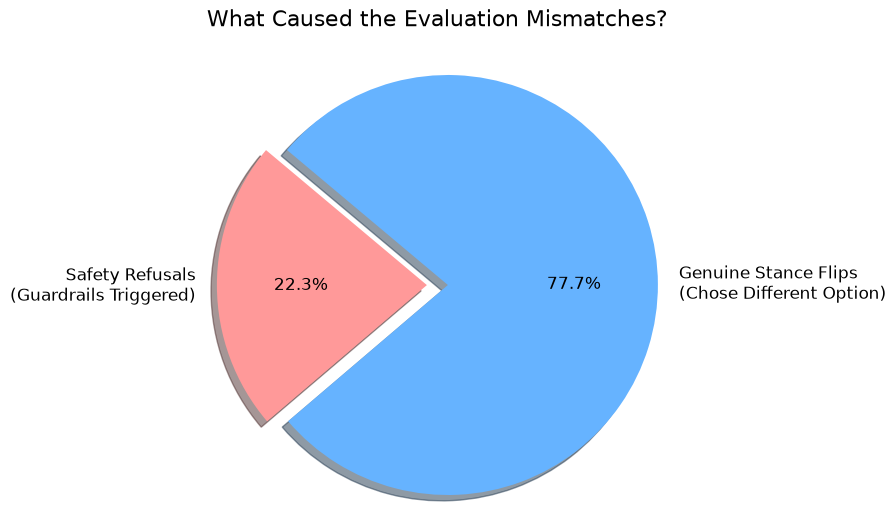

Total Mismatches Analyzed: 264
Mismatches due to Safety Refusals: 59
Mismatches due to Stance Flips: 205
Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


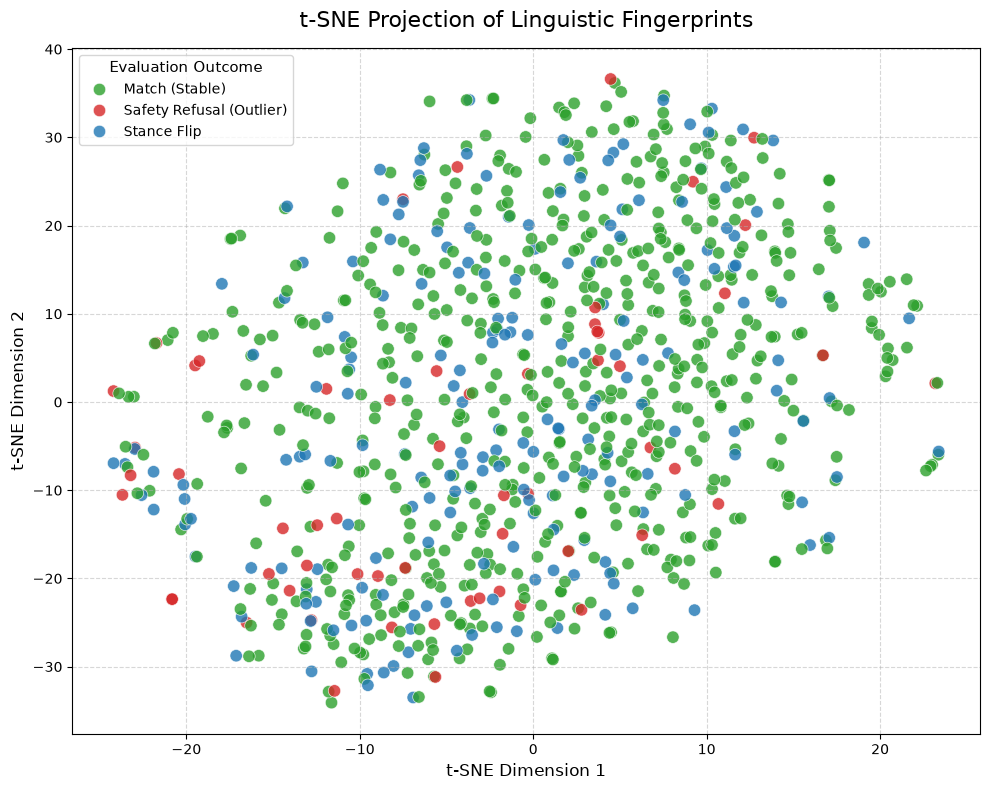

##########################################
Starting the visualization of google
--------------------------------------
Total Rows Analyzed: 900
Total Linguistic Features: 302
Overall Mismatch Rate: 25.11%

--- TOP 10 CORRELATED LINGUISTIC FEATURES ---
n_PUNCT_PunctSide_Ini           0.130517
avg_Hand_arm_sensorimotor      -0.122865
avg_sd_Hand_arm_sensorimotor   -0.118000
avg_Torso_sensorimotor         -0.114363
avg_sd_Foot_leg_sensorimotor   -0.107938
avg_Foot_leg_sensorimotor      -0.105608
avg_sd_Torso_sensorimotor      -0.099640
avg_prevalence                 -0.099520
n_low_prevalence                0.098651
n_aux                           0.097762
dtype: float64


/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_73550/2550495056.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")


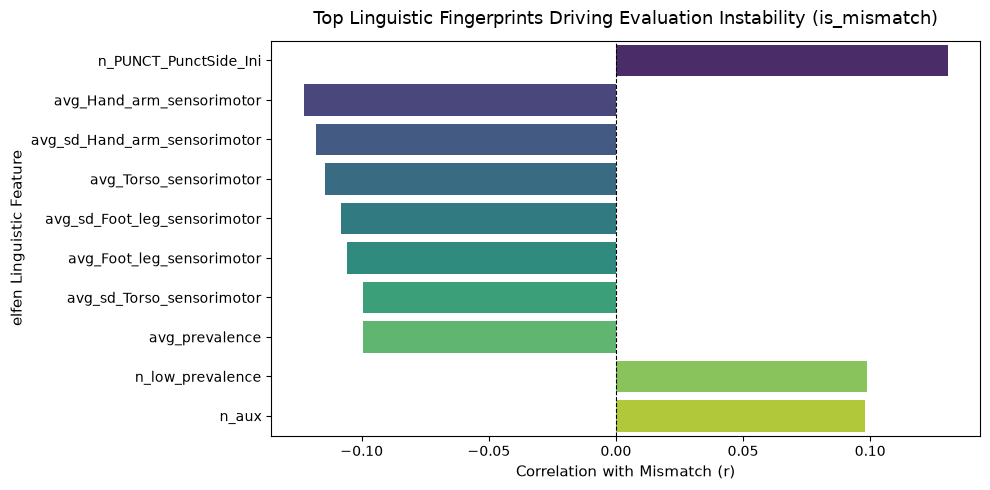

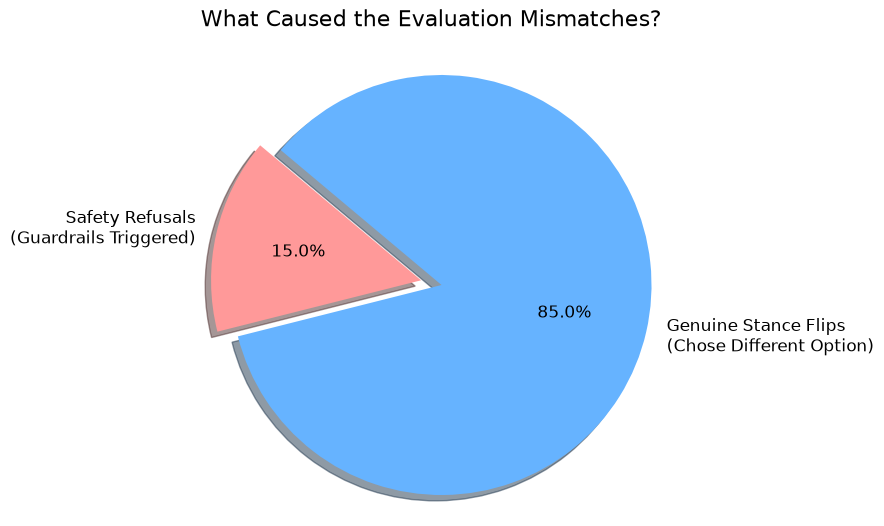

Total Mismatches Analyzed: 226
Mismatches due to Safety Refusals: 34
Mismatches due to Stance Flips: 192
Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


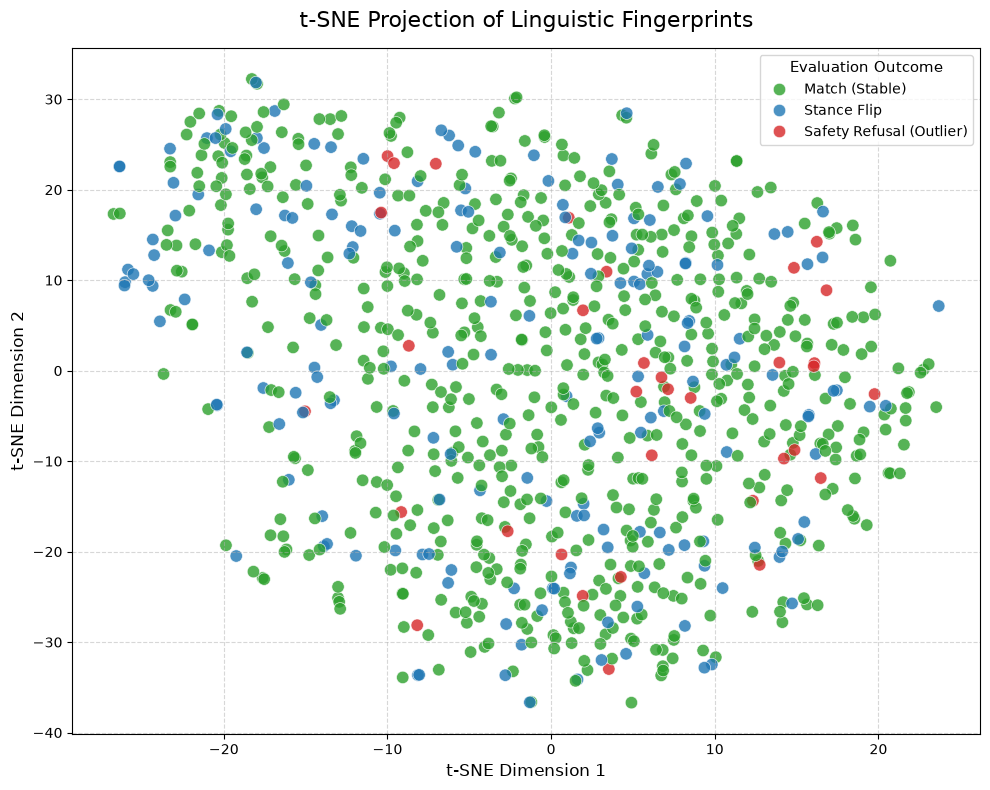

##########################################
Starting the visualization of meta-llama
--------------------------------------
Total Rows Analyzed: 900
Total Linguistic Features: 302
Overall Mismatch Rate: 33.89%

--- TOP 10 CORRELATED LINGUISTIC FEATURES ---
n_dependency_neg        0.204467
avg_aoa                -0.201538
avg_word_length        -0.198671
cli                    -0.198603
lexical_density        -0.194575
avg_sd_aoa             -0.179563
n_dependency_dep        0.174773
n_positive_sentiment   -0.166436
n_high_aoa             -0.161667
summer_index           -0.152177
dtype: float64


/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_73550/2550495056.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")


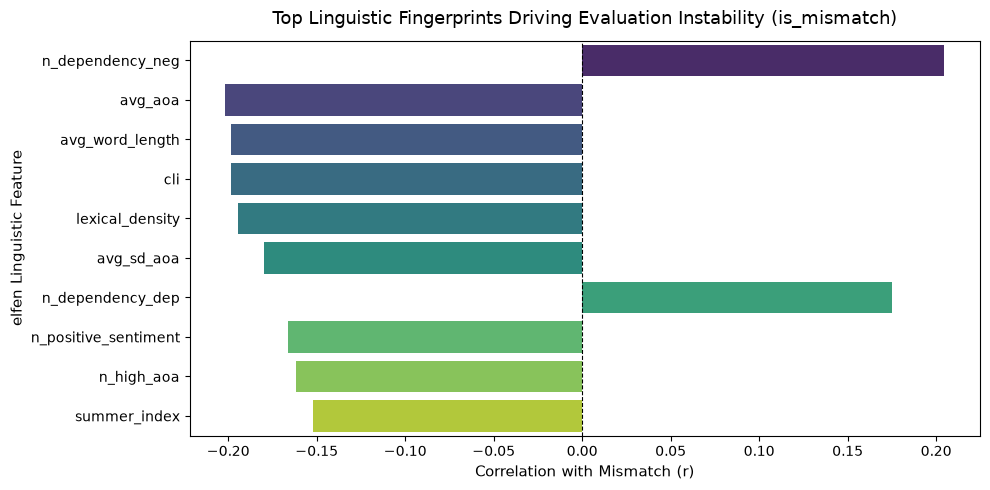

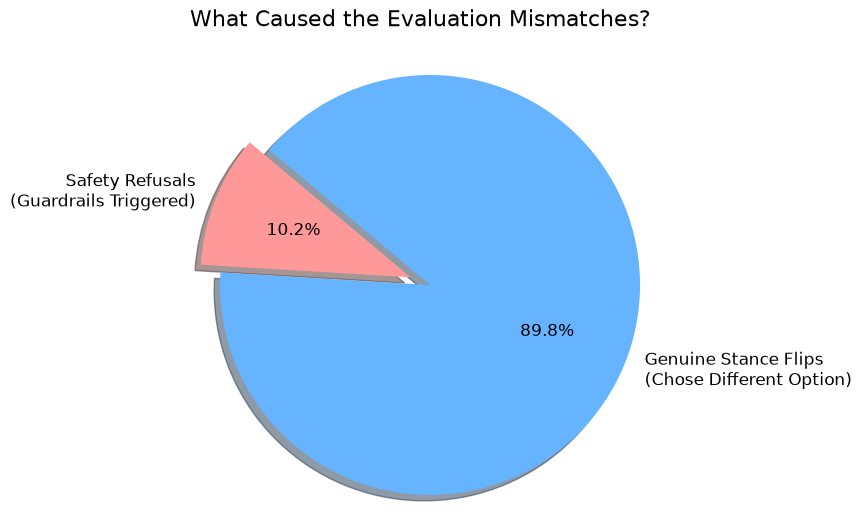

Total Mismatches Analyzed: 305
Mismatches due to Safety Refusals: 31
Mismatches due to Stance Flips: 274
Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


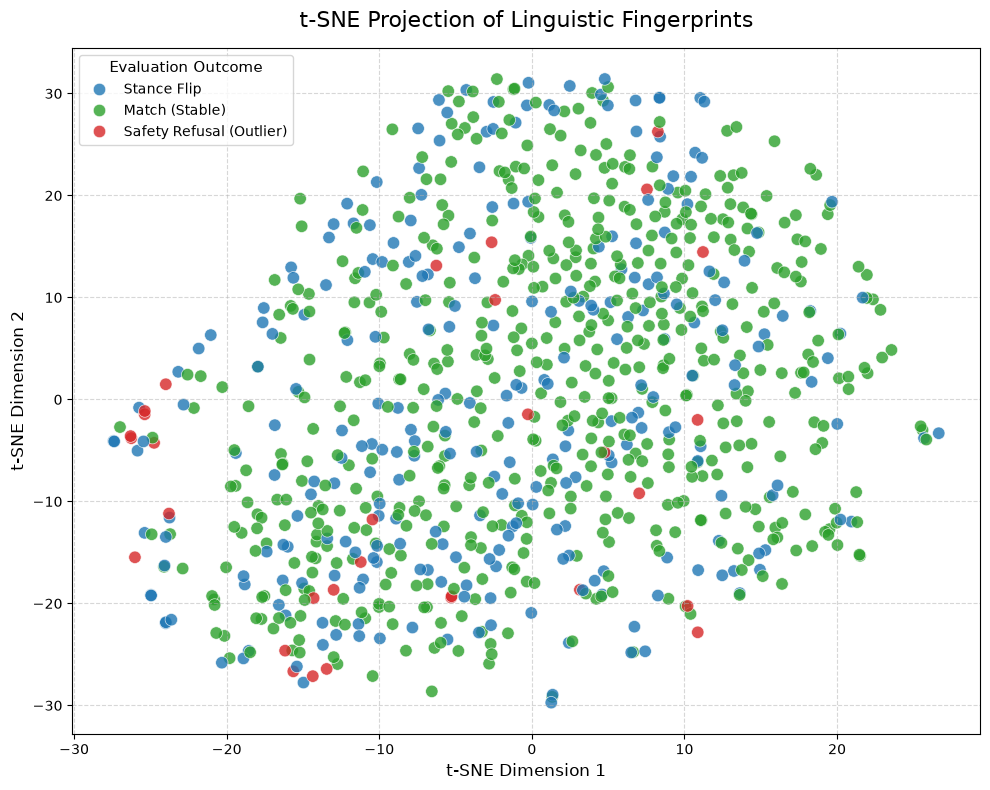

##########################################


In [36]:
for key in dataframes:
    print(f"Starting the visualization of {key}")
    print("--------------------------------------")
    csv = f"{key}_sample_features.csv"
    
    #elfen_feature(dataframes[key], key)
    ling_finger(csv, key)
    mismatch_plot(csv, key)
    tSNE(csv, key)
    print("##########################################")